# PE2 Stage 7: model optimization and final evaluation
Tune RF and SVC on the Stage 6 folds, test one RF feature extension, select one model using CV, then assess that choice on 2017/12/23.

The saved search CSVs contain the completed 50-configuration searches. Reuse them when present; the explicit search code remains visible for reproduction. No search settings or final model choice are changed by rerunning this notebook.

In [1]:
from pathlib import Path
import sys
import ast
import json
import joblib
from joblib import parallel_config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.pe2_transformers import SoundTertileEncoder

DATA, RESULTS = ROOT / "data/pe1_preprocessing", ROOT / "results/pe2"
FIGURES, MODELS = RESULTS / "figures", ROOT / "models"
FIGURES.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(exist_ok=True)
SEED, CLASSES, TEST_DATE = 42, [0, 1, 2, 3], "2017/12/23"
TARGET = "Room_Occupancy_Count"
RAW_SENSORS = [f"S{i}_{kind}" for kind in ["Temp", "Light", "Sound"] for i in range(1, 5)]

## 1. Recreate the Stage 6 CV setup
Use the same row order, date/half-hour blocks, four folds, shuffle setting and seed. Session date and block identifiers are never predictors. The precomputed sound category is removed and recreated inside every pipeline; SVC also scales inside each fold.

In [2]:
X_train = pd.read_csv(DATA / "X_train.csv")
y_train = pd.read_csv(DATA / "y_train.csv")[TARGET]
prepared = pd.read_csv(DATA / "Occupancy_Estimation_prepared.csv")
training_rows = prepared.loc[prepared["Session_Date"] != TEST_DATE].reset_index(drop=True)
del prepared
assert X_train.shape == (7350, 13) and len(y_train) == len(training_rows) == 7350
assert set(y_train) == set(CLASSES)
assert np.allclose(X_train, training_rows[X_train.columns])
assert np.array_equal(y_train, training_rows[TARGET])
X_compact = X_train.drop(columns="Sound_Level_Code")
X_extended = pd.concat([X_compact, training_rows[RAW_SENSORS]], axis=1)
assert not X_extended.isna().any().any() and not y_train.isna().any()
assert not {"Session_Date", "Temporal_Block", TARGET}.intersection(X_extended.columns)

groups = training_rows["Session_Date"] + "_" + np.floor(
    training_rows["Time_of_Day_Minutes"] / 30).astype(int).astype(str)
cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
splits = list(cv.split(X_compact, y_train, groups))
fold_counts = []
for fold, (train_idx, valid_idx) in enumerate(splits, 1):
    assert not set(groups.iloc[train_idx]).intersection(groups.iloc[valid_idx])
    for part, idx in [("train", train_idx), ("validation", valid_idx)]:
        counts = y_train.iloc[idx].value_counts().reindex(CLASSES, fill_value=0)
        assert (counts > 0).all()
        fold_counts.append([fold, part, *counts.tolist()])
display(pd.DataFrame(fold_counts, columns=["fold", "part", "class_0", "class_1", "class_2", "class_3"]))

,fold,part,class_0,class_1,class_2,class_3
0,1,train,4649,144,245,426
1,1,validation,1582,61,105,138
2,2,train,4687,151,286,427
3,2,validation,1544,54,64,137
4,3,train,4681,145,253,423
5,3,validation,1550,60,97,141
6,4,train,4676,175,266,416
7,4,validation,1555,30,84,148


## 2. Tune Random Forest
Fifty random settings avoid the huge exhaustive RF grid. Optimize macro F1, which weights all occupancy counts equally, and keep training scores to inspect overfitting. SearchCV's `test_score` columns mean internal validation folds, **not** the reserved session.

SearchCV uses all workers; each RF fit uses one worker to avoid nested parallelism. Class weights remain a choice because weighting hurt Stage 6 RF performance.

In [3]:
rf_pipeline = Pipeline([
    ("sound", SoundTertileEncoder()),
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=1)),
])
rf_space = {
    "model__n_estimators": [200, 300, 400, 600, 800],
    "model__max_depth": [None, 6, 8, 10, 12, 16, 20, 24],
    "model__min_samples_split": [2, 4, 6, 10, 15, 20],
    "model__min_samples_leaf": [1, 2, 3, 4, 6, 8],
    "model__max_features": ["sqrt", "log2", 0.5, 0.75, None],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced", "balanced_subsample"],
}
rf_search_path = RESULTS / "hyperparameter_search_rf.csv"
if rf_search_path.exists():
    rf_search_results = pd.read_csv(rf_search_path)
else:
    rf_search = RandomizedSearchCV(
        rf_pipeline, rf_space, n_iter=50, scoring="f1_macro", refit=True,
        cv=splits, random_state=SEED, n_jobs=-1, pre_dispatch="n_jobs",
        return_train_score=True, error_score="raise",
    )
    with parallel_config(backend="loky", inner_max_num_threads=1):
        rf_search.fit(X_compact, y_train)
    rf_search_results = pd.DataFrame(rf_search.cv_results_)
    rf_search_results["train_validation_gap"] = (
        rf_search_results["mean_train_score"] - rf_search_results["mean_test_score"])
    rf_search_results.to_csv(rf_search_path, index=False)

rf_best_row = rf_search_results.sort_values("rank_test_score").iloc[0]
rf_best_params = ast.literal_eval(str(rf_best_row["params"]))
rf_tuned = clone(rf_pipeline).set_params(**rf_best_params)
display(rf_search_results.sort_values("rank_test_score")[
    ["rank_test_score", "mean_train_score", "mean_test_score", "std_test_score", "params"]
].head())
print("Best RF parameters:", rf_best_params)

,rank_test_score,mean_train_score,mean_test_score,std_test_score,params
26,1,0.999807,0.866818,0.025008,"{'model__n_estimators': 800, 'model__min_sampl..."
25,2,0.993598,0.866690,0.024807,"{'model__n_estimators': 400, 'model__min_sampl..."
19,3,0.992501,0.860890,0.019488,"{'model__n_estimators': 300, 'model__min_sampl..."
34,4,0.991822,0.860422,0.017551,"{'model__n_estimators': 200, 'model__min_sampl..."
29,5,0.992301,0.860252,0.017159,"{'model__n_estimators': 800, 'model__min_sampl..."


Best RF parameters: {'model__n_estimators': 800, 'model__min_samples_split': 4, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None, 'model__criterion': 'gini', 'model__class_weight': None}


**Best RF:** `n_estimators=800`, `max_depth=None`, `min_samples_split=4`, `min_samples_leaf=1`, `max_features="log2"`, `criterion="gini"`, `class_weight=None`.

Training macro F1 is 0.9998 versus validation 0.8668: the forest fits the known sessions much more easily than withheld blocks. A 400-tree, depth-10 setting is almost tied at 0.8667, so the tiny ranking gap does not prove unlimited depth is inherently better.

## 3. Tune the balanced-SVC candidate
Keep an RBF kernel and search C, gamma and class weighting. C controls the penalty for training errors; gamma controls how local the boundary is. Fifty of the 112 combinations are sampled on the same folds. Probabilities are unnecessary and remain disabled by default.

In [4]:
svc_pipeline = Pipeline([
    ("sound", SoundTertileEncoder()), ("scale", StandardScaler()),
    ("model", SVC(random_state=SEED)),
])
svc_space = {
    "model__C": [0.1, 0.3, 1, 3, 10, 30, 100],
    "model__gamma": ["scale", 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1],
    "model__class_weight": [None, "balanced"],
    "model__kernel": ["rbf"],
}
svc_search_path = RESULTS / "hyperparameter_search_svc.csv"
if svc_search_path.exists():
    svc_search_results = pd.read_csv(svc_search_path)
else:
    svc_search = RandomizedSearchCV(
        svc_pipeline, svc_space, n_iter=50, scoring="f1_macro", refit=True,
        cv=splits, random_state=SEED, n_jobs=-1, pre_dispatch="n_jobs",
        return_train_score=True, error_score="raise",
    )
    with parallel_config(backend="loky", inner_max_num_threads=1):
        svc_search.fit(X_compact, y_train)
    svc_search_results = pd.DataFrame(svc_search.cv_results_)
    svc_search_results["train_validation_gap"] = (
        svc_search_results["mean_train_score"] - svc_search_results["mean_test_score"])
    svc_search_results.to_csv(svc_search_path, index=False)

svc_best_row = svc_search_results.sort_values("rank_test_score").iloc[0]
svc_best_params = ast.literal_eval(str(svc_best_row["params"]))
svc_tuned = clone(svc_pipeline).set_params(**svc_best_params)
display(svc_search_results.sort_values("rank_test_score")[
    ["rank_test_score", "mean_train_score", "mean_test_score", "std_test_score", "params"]
].head())
print("Best SVC parameters:", svc_best_params)

,rank_test_score,mean_train_score,mean_test_score,std_test_score,params
45,1,0.959932,0.888101,0.048961,"{'model__kernel': 'rbf', 'model__gamma': 0.001..."
24,2,0.968664,0.879595,0.075106,"{'model__kernel': 'rbf', 'model__gamma': 0.003..."
13,3,0.955613,0.877661,0.064633,"{'model__kernel': 'rbf', 'model__gamma': 0.001..."
19,4,0.988279,0.867389,0.038717,"{'model__kernel': 'rbf', 'model__gamma': 0.01,..."
23,5,0.952813,0.854973,0.038266,"{'model__kernel': 'rbf', 'model__gamma': 0.003..."


Best SVC parameters: {'model__kernel': 'rbf', 'model__gamma': 0.001, 'model__class_weight': 'balanced', 'model__C': 100}


**Best SVC:** `kernel="rbf"`, `C=100`, `gamma=0.001`, `class_weight="balanced"`. Training macro F1 is 0.9599 versus validation 0.8881. It has a smaller training-validation gap than compact RF, but varies more across folds.

## 4. Compare baseline versus tuned models
A single helper handles the repeated CV evaluation for compact RF, SVC and extended RF. Each fold fits its own preprocessing. Fold means/SD are comparable with Stage 6; per-class recalls use pooled OOF predictions.

These are the same folds used for tuning, so tuned OOF scores are selection-biased internal evidence, not an independent final assessment. Macro-F1 SD uses ddof=1; the search CSVs use SearchCV's ddof=0 convention.

Random Forest - tuned compact


              precision    recall  f1-score   support

           0     0.9911    0.9955    0.9933      6231
           1     1.0000    0.9756    0.9877       205
           2     0.7596    0.7314    0.7453       350
           3     0.7798    0.7660    0.7728       564

    accuracy                         0.9648      7350
   macro avg     0.8826    0.8671    0.8748      7350
weighted avg     0.9641    0.9648    0.9644      7350



,0,1,2,3
0,6203,0,0,28
1,2,200,3,0
2,0,0,256,94
3,54,0,78,432


SVC - tuned compact
              precision    recall  f1-score   support

           0     0.9885    0.9952    0.9918      6231
           1     0.9018    0.9854    0.9417       205
           2     0.7780    0.9114    0.8395       350
           3     0.8962    0.7039    0.7885       564

    accuracy                         0.9686      7350
   macro avg     0.8911    0.8990    0.8904      7350
weighted avg     0.9690    0.9686    0.9676      7350



,0,1,2,3
0,6201,11,0,19
1,0,202,3,0
2,0,4,319,27
3,72,7,88,397


,model,stage,feature_set,predictor_count_after_sound_encoding,cv_mean_accuracy,cv_mean_balanced_accuracy,cv_mean_macro_precision,cv_mean_macro_recall,cv_mean_macro_f1,cv_mean_weighted_f1,cv_std_macro_f1,class_0_recall,class_1_recall,class_2_recall,class_3_recall,cv_mean_train_macro_f1,cv_mean_train_validation_gap
0,Random Forest - baseline,Stage 6,compact,13,0.9655,0.8585,0.9005,0.8585,0.8657,0.9639,0.0344,0.9973,0.9707,0.7343,0.7535,NaN,NaN
1,SVC - balanced baseline,Stage 6,compact,13,0.9574,0.8628,0.8543,0.8628,0.8223,0.9558,0.0623,0.9819,0.9756,0.7543,0.8050,NaN,NaN
2,Random Forest - tuned compact,Stage 7,compact,13,0.9650,0.8614,0.9021,0.8614,0.8668,0.9635,0.0289,0.9955,0.9756,0.7314,0.7660,0.9998,0.1330
3,SVC - tuned compact,Stage 7,compact,13,0.9686,0.8997,0.8943,0.8997,0.8881,0.9667,0.0565,0.9952,0.9854,0.9114,0.7039,0.9599,0.0718


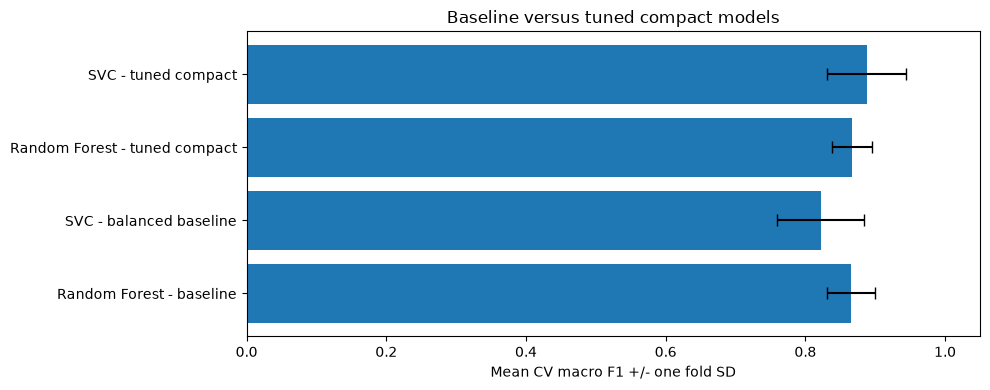

In [5]:
def metrics(truth, prediction):
    return {
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": balanced_accuracy_score(truth, prediction),
        "macro_precision": precision_score(truth, prediction, average="macro", zero_division=0),
        "macro_recall": recall_score(truth, prediction, average="macro", zero_division=0),
        "macro_f1": f1_score(truth, prediction, average="macro", zero_division=0),
        "weighted_f1": f1_score(truth, prediction, average="weighted", zero_division=0),
    }

def evaluate_model(name, pipeline, X):
    prediction = np.zeros(len(y_train), dtype=int)
    fold_scores = []
    for train_idx, valid_idx in splits:
        fitted = clone(pipeline).fit(X.iloc[train_idx], y_train.iloc[train_idx])
        prediction[valid_idx] = fitted.predict(X.iloc[valid_idx])
        scores = metrics(y_train.iloc[valid_idx], prediction[valid_idx])
        scores["train_macro_f1"] = f1_score(
            y_train.iloc[train_idx], fitted.predict(X.iloc[train_idx]), average="macro")
        fold_scores.append(scores)
    scores = pd.DataFrame(fold_scores)
    report = classification_report(y_train, prediction, labels=CLASSES, output_dict=True, zero_division=0)
    row = {
        "model": name, "stage": "Stage 7",
        "feature_set": "extended" if X.shape[1] == 24 else "compact",
        "predictor_count_after_sound_encoding": X.shape[1] + 1,
        **{f"cv_mean_{m}": scores[m].mean() for m in metrics(y_train, prediction)},
        "cv_std_macro_f1": scores["macro_f1"].std(ddof=1),
        "cv_mean_train_macro_f1": scores["train_macro_f1"].mean(),
        "cv_mean_train_validation_gap": (scores["train_macro_f1"] - scores["macro_f1"]).mean(),
        **{f"class_{c}_recall": report[str(c)]["recall"] for c in CLASSES},
    }
    print(name)
    print(classification_report(y_train, prediction, labels=CLASSES, digits=4, zero_division=0))
    display(pd.DataFrame(confusion_matrix(y_train, prediction, labels=CLASSES), index=CLASSES, columns=CLASSES))
    return row

rf_result = evaluate_model("Random Forest - tuned compact", rf_tuned, X_compact)
svc_result = evaluate_model("SVC - tuned compact", svc_tuned, X_compact)

baseline = pd.read_csv(RESULTS / "baseline_model_comparison.csv").set_index("experiment")
baseline_rows = []
for name in ["Random Forest - baseline", "SVC - balanced"]:
    old = baseline.loc[name]
    baseline_rows.append({
        "model": name if name.startswith("Random") else "SVC - balanced baseline",
        "stage": "Stage 6", "feature_set": "compact", "predictor_count_after_sound_encoding": 13,
        **{k: old[k] for k in old.index if k.startswith(("cv_", "class_"))},
    })
comparison = pd.DataFrame([*baseline_rows, rf_result, svc_result])
comparison.to_csv(RESULTS / "tuned_model_comparison.csv", index=False)
display(comparison.round(4))
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(comparison["model"], comparison["cv_mean_macro_f1"],
        xerr=comparison["cv_std_macro_f1"], capsize=4)
ax.set(xlabel="Mean CV macro F1 +/- one fold SD", xlim=(0, 1.05),
       title="Baseline versus tuned compact models")
fig.tight_layout()
fig.savefig(FIGURES / "stage7_baseline_vs_tuned_macro_f1.png", dpi=160)
plt.show()
plt.close(fig)

**What tuning changed.** RF macro F1 rises only from 0.8657 to 0.8668 (+0.0012). SVC rises from 0.8223 to 0.8881 (+0.0658). SVC's class-2 recall improves to 0.9114, but class-3 recall falls to 0.7039. Higher mean performance does not mean every occupied count improves.

## 5. Compact versus extended RF features
Keep the best RF settings and all folds fixed; add the 12 original temperature/light/sound sensors. Do not run a second search. The original practical rule was that a macro-F1 gain below 0.01 alone would not justify doubling the classifier inputs from 13 to 25.

The `max_features="log2"` rule remains fixed, but its effective count changes from three predictors per split to four as the feature set grows.

Random Forest - tuned extended
              precision    recall  f1-score   support

           0     0.9912    0.9971    0.9942      6231
           1     1.0000    0.9854    0.9926       205
           2     0.8374    0.7800    0.8077       350
           3     0.8285    0.8138    0.8211       564

    accuracy                         0.9724      7350
   macro avg     0.9143    0.8941    0.9039      7350
weighted avg     0.9717    0.9724    0.9720      7350



,0,1,2,3
0,6213,0,0,18
1,0,202,3,0
2,0,0,273,77
3,55,0,50,459


,model,stage,feature_set,predictor_count_after_sound_encoding,cv_mean_accuracy,cv_mean_balanced_accuracy,cv_mean_macro_precision,cv_mean_macro_recall,cv_mean_macro_f1,cv_mean_weighted_f1,cv_std_macro_f1,cv_mean_train_macro_f1,cv_mean_train_validation_gap,class_0_recall,class_1_recall,class_2_recall,class_3_recall
0,Random Forest - tuned compact,Stage 7,compact,13,0.9650,0.8614,0.9021,0.8614,0.8668,0.9635,0.0289,0.9998,0.1330,0.9955,0.9756,0.7314,0.7660
1,Random Forest - tuned extended,Stage 7,extended,25,0.9726,0.8931,0.9267,0.8931,0.9015,0.9713,0.0422,0.9993,0.0978,0.9971,0.9854,0.7800,0.8138


Extended-minus-compact macro F1: 0.03469585135244435


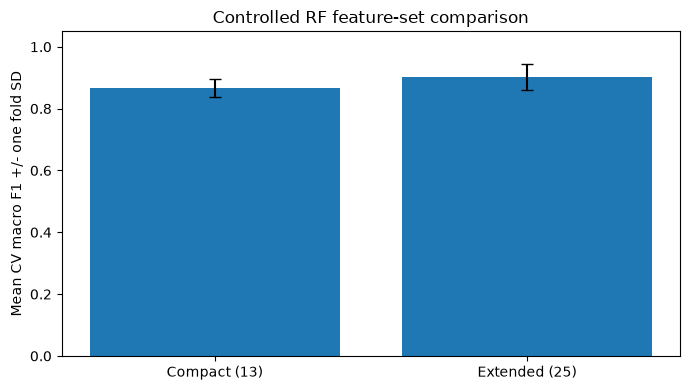

In [6]:
extended_result = evaluate_model("Random Forest - tuned extended", rf_tuned, X_extended)
feature_comparison = pd.DataFrame([rf_result, extended_result])
feature_comparison.to_csv(RESULTS / "feature_set_comparison.csv", index=False)
display(feature_comparison.round(4))
print("Extended-minus-compact macro F1:",
      extended_result["cv_mean_macro_f1"] - rf_result["cv_mean_macro_f1"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(["Compact (13)", "Extended (25)"], feature_comparison["cv_mean_macro_f1"],
       yerr=feature_comparison["cv_std_macro_f1"], capsize=4)
ax.set(ylabel="Mean CV macro F1 +/- one fold SD", ylim=(0, 1.05),
       title="Controlled RF feature-set comparison")
fig.tight_layout()
fig.savefig(FIGURES / "stage7_rf_feature_set_comparison.png", dpi=160)
plt.show()
plt.close(fig)

Adding raw sensors raises macro F1 from 0.8668 to 0.9015 (+0.0347). Recalls improve for counts 1/2/3 from 0.9756/0.7314/0.7660 to 0.9854/0.7800/0.8138. Fold SD rises from 0.0289 to 0.0422, while the train-validation gap falls from 0.1330 to 0.0978. The gain exceeds the original 0.01 practical threshold and justifies the added inputs for this experiment.

## 6. Final Model Selection Before Test Evaluation
**Keep the selected tuned RF with extended features.** It has the highest CV macro F1 (0.9015), better worst occupied-class recall than SVC (0.7800 versus 0.7039), and lower fold SD (0.0422 versus 0.0565).

SVC has slightly better balanced accuracy (0.8997 versus RF's 0.8931), better class-2 recall and a smaller training-validation gap. RF uses more features and 800 trees, but its macro-F1 and worst-class-recall gains support the original choice. These are descriptive differences, not a significance claim.

The next cell saves this training/CV decision before loading the test CSVs. The final model choice is unchanged.

In [7]:
selected_name = "Random Forest - tuned extended"
best_rf = {key.removeprefix("model__"): value for key, value in rf_best_params.items()}
best_rf.update(random_state=SEED, n_jobs=1)
selection = {
    "selected_model": selected_name, "feature_set": "extended",
    "hyperparameters": best_rf,
    "cv_mean_macro_f1": extended_result["cv_mean_macro_f1"],
    "cv_std_macro_f1": extended_result["cv_std_macro_f1"],
    "cv_mean_balanced_accuracy": extended_result["cv_mean_balanced_accuracy"],
    "selected_before_test_evaluation": True,
    "reason": "Highest CV macro F1, better minimum occupied-class recall and lower fold variability than tuned SVC; the raw-sensor gain justifies the added features.",
}
with (RESULTS / "final_model_selection.json").open("w", encoding="utf-8") as handle:
    json.dump(selection, handle, indent=2)
print(selection)

{'selected_model': 'Random Forest - tuned extended', 'feature_set': 'extended', 'hyperparameters': {'n_estimators': 800, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini', 'class_weight': None, 'random_state': 42, 'n_jobs': 1}, 'cv_mean_macro_f1': np.float64(0.9015142534938398), 'cv_std_macro_f1': np.float64(0.04224772838114464), 'cv_mean_balanced_accuracy': np.float64(0.8930609618284748), 'selected_before_test_evaluation': True, 'reason': 'Highest CV macro F1, better minimum occupied-class recall and lower fold variability than tuned SVC; the raw-sensor gain justifies the added features.'}


## 7. Evaluate only the selected model on the held-out session
The completed project already contains the fitted final pipeline. Reuse it to verify the frozen result. If reproducing without that file, fit the same selected pipeline on all training rows. No alternative model is tested and no settings are changed after seeing the test scores.

This cell contains one final assessment of the selected model. Rerunning the notebook verifies the same fixed result; it is not a new tuning or model-selection experiment.

In [8]:
X_test = pd.read_csv(DATA / "X_test.csv")
y_test = pd.read_csv(DATA / "y_test.csv")[TARGET]
prepared = pd.read_csv(DATA / "Occupancy_Estimation_prepared.csv")
test_rows = prepared.loc[prepared["Session_Date"] == TEST_DATE].reset_index(drop=True)
del prepared
assert X_test.shape == (2779, 13) and len(y_test) == len(test_rows) == 2779
assert set(y_test) == set(CLASSES)
assert np.allclose(X_test, test_rows[X_test.columns])
assert np.array_equal(y_test, test_rows[TARGET])
X_test_extended = pd.concat([X_test.drop(columns="Sound_Level_Code"), test_rows[RAW_SENSORS]], axis=1)
assert not X_test_extended.isna().any().any()
assert X_test_extended.columns.tolist() == X_extended.columns.tolist()

model_path = MODELS / "room_occupancy_final_model.joblib"
if model_path.exists():
    final_model = joblib.load(model_path)
else:
    final_model = clone(rf_tuned).fit(X_extended, y_train)
assert all(final_model.named_steps["model"].get_params()[k] == v for k, v in best_rf.items())
test_prediction = final_model.predict(X_test_extended)
assert len(test_prediction) == 2779 and set(test_prediction).issubset(CLASSES)

test_metrics = metrics(y_test, test_prediction)
test_report = classification_report(y_test, test_prediction, labels=CLASSES, output_dict=True, zero_division=0)
per_class = pd.DataFrame({c: test_report[str(c)] for c in CLASSES}).T.rename_axis("class").reset_index()
matrix = confusion_matrix(y_test, test_prediction, labels=CLASSES)
matrix_table = pd.DataFrame(matrix, columns=[f"predicted_{c}" for c in CLASSES])
matrix_table.insert(0, "true_class", CLASSES)
pd.DataFrame([test_metrics]).to_csv(RESULTS / "final_test_metrics.csv", index=False)
per_class.to_csv(RESULTS / "final_test_classification_report.csv", index=False)
matrix_table.to_csv(RESULTS / "final_test_confusion_matrix.csv", index=False)
display(pd.DataFrame([test_metrics]).round(4))
display(per_class.round(4))
display(matrix_table)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,0.9489,0.9115,0.8674,0.9115,0.8586,0.9525


,class,precision,recall,f1-score,support
0,0,1.0000,0.9980,0.9990,1997.0
1,1,0.9922,1.0000,0.9961,254.0
2,2,0.9962,0.6558,0.7909,398.0
3,3,0.4813,0.9923,0.6482,130.0


,true_class,predicted_0,predicted_1,predicted_2,predicted_3
0,0,1993,1,0,3
1,1,0,254,0,0
2,2,0,1,261,136
3,3,0,0,1,129


## 8. Interpret the confusion matrix
Test accuracy is 0.9489 and macro F1 is 0.8586, down 0.0430 from CV. Balanced accuracy rises to 0.9115. The main error is **136 true count-2 rows predicted as count 3**. Class-2 recall is 0.6558; class-3 recall is 0.9923 but precision is only 0.4813, leaving class-3 F1 at 0.6482.

The test day contains 14.32% class 2 versus 4.76% in training. Session/environment changes and this class-distribution shift may explain some of the gap, but cannot establish one cause. Do not retune on the test day.

,evaluation,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,CV mean,0.9726,0.8931,0.9267,0.8931,0.9015,0.9713
1,Held-out test,0.9489,0.9115,0.8674,0.9115,0.8586,0.9525


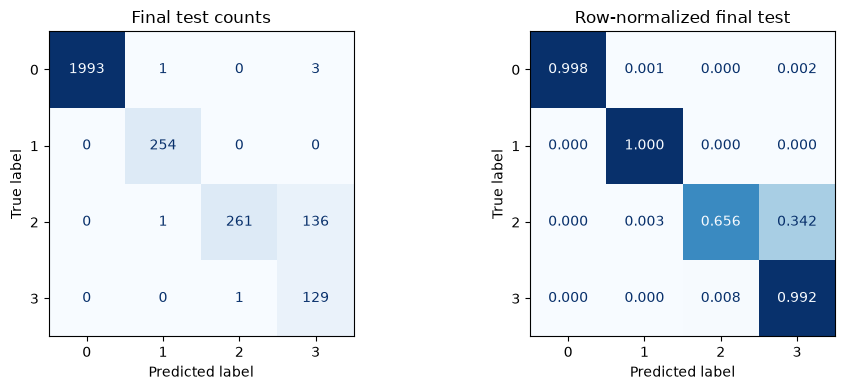

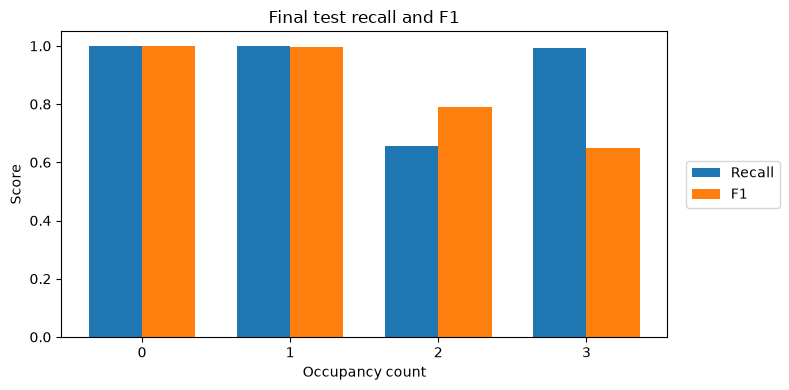

In [9]:
cv_test = pd.DataFrame([
    {"evaluation": "CV mean", **{m: extended_result[f"cv_mean_{m}"] for m in test_metrics}},
    {"evaluation": "Held-out test", **test_metrics},
])
display(cv_test.round(4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(matrix, display_labels=CLASSES).plot(
    ax=axes[0], colorbar=False, cmap="Blues", values_format="d")
ConfusionMatrixDisplay(matrix / matrix.sum(axis=1, keepdims=True), display_labels=CLASSES).plot(
    ax=axes[1], colorbar=False, cmap="Blues", values_format=".3f", im_kw={"vmin": 0, "vmax": 1})
axes[0].set_title("Final test counts")
axes[1].set_title("Row-normalized final test")
fig.tight_layout()
fig.savefig(FIGURES / "stage7_final_test_confusion_matrix.png", dpi=160)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(4)
ax.bar(positions - 0.18, per_class["recall"], width=0.36, label="Recall")
ax.bar(positions + 0.18, per_class["f1-score"], width=0.36, label="F1")
ax.set(xticks=positions, xticklabels=CLASSES, xlabel="Occupancy count",
       ylabel="Score", ylim=(0, 1.05), title="Final test recall and F1")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.tight_layout()
fig.savefig(FIGURES / "stage7_final_test_recall_f1.png", dpi=160)
plt.show()
plt.close(fig)

## 9. Save the final pipeline and verify loading
The pipeline includes the fitted sound encoder. `src/pe2_transformers.py` must remain importable when loading it. Preserve the existing model binary; only create it when reproducing without the saved file. Keep metadata limited to the model's inputs, settings and results.

In [10]:
if not model_path.exists():
    joblib.dump(final_model, model_path)
reloaded_model = joblib.load(model_path)
assert np.array_equal(reloaded_model.predict(X_test_extended), test_prediction)

model_metadata = {
    "selected_model": selected_name, "feature_set": "extended",
    "input_features": X_extended.columns.tolist(), "generated_features": ["Sound_Level_Code"],
    "target": TARGET, "target_classes": CLASSES,
    "hyperparameters": best_rf, "transformer_import": "src.pe2_transformers.SoundTertileEncoder",
    "sound_thresholds": final_model.named_steps["sound"].thresholds_.tolist(),
    "cv_strategy": "4-fold StratifiedGroupKFold; 30-minute blocks; shuffle=True; random_state=42",
    "cv_macro_f1": extended_result["cv_mean_macro_f1"],
    "cv_macro_f1_sd": extended_result["cv_std_macro_f1"],
    "held_out_test_session": TEST_DATE, "training_rows": 7350, "test_rows": 2779,
    "test_metrics": test_metrics,
}
with (MODELS / "room_occupancy_final_model_metadata.json").open("w", encoding="utf-8") as handle:
    json.dump(model_metadata, handle, indent=2)
print("Final model loaded successfully; reloaded predictions match.")
print("Final test scores were not used to retune or replace the selected model.")

Final model loaded successfully; reloaded predictions match.
Final test scores were not used to retune or replace the selected model.


## PE2 viva summary
Four baseline families compared linear, nearest-neighbor, tree and nonlinear-kernel behavior. RF and balanced SVC were chosen for their complementary macro-F1 and occupied-class-recall strengths. Fifty random parameter combinations per family kept tuning manageable.

Imbalance handling was model-dependent: weighting hurt RF; balanced SVC improved balanced accuracy; KNN oversampling helped moderately; balanced Logistic Regression improved balanced accuracy but reduced macro F1. This explains why class weighting was searched rather than imposed.

RF tuning alone barely helped; SVC tuning helped substantially. The single raw-sensor extension improved RF enough to justify its extra features, so extended RF was selected before the final test. It reached test macro F1 0.8586, with two-versus-three-person confusion as its main weakness.

Temporal groups reduce nearby-row overlap, but neighboring blocks can remain dependent. The same folds were used for tuning and comparison, class 1 occurs in only one training session, and one test day in one room limits generalization claims. The final test did not trigger another search or a model change.